<a href="https://colab.research.google.com/github/SkinHeadDressSom/Ultimate-X-ray-AI/blob/main/CXR_YOLO_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q ultralytics
!pip install -U -q albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 911.6/911.6 kB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.9/273.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 632.7/632.7 kB 27.7 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import torch
import os
import cv2
from matplotlib import pyplot as plt
import random

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [5]:
test_images_path = "/content/drive/MyDrive/UltimateXray/YOLO/images/test"
model_path = "/content/drive/MyDrive/UltimateXray/model/UltimateXray_yolov11x/weights/best.pt"

In [6]:
model = YOLO(model_path)
test_images = os.listdir(test_images_path)

In [45]:
random_image_name = random.choice(test_images)
random_image_path = os.path.join(test_images_path, random_image_name)

image = cv2.imread(random_image_path, cv2.IMREAD_GRAYSCALE)
equalized_image = cv2.equalizeHist(image)

temp_path = "/content/temp_equalized_image.jpg"
cv2.imwrite(temp_path, equalized_image)

True

In [46]:
results = model(temp_path)


image 1/1 /content/temp_equalized_image.jpg: 640x640 2 Cardiomegalys, 1 Aortic enlargement, 93.2ms
Speed: 2.0ms preprocess, 93.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


In [47]:
result = results[0]
result_image = result.plot(show=False)

In [48]:
result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

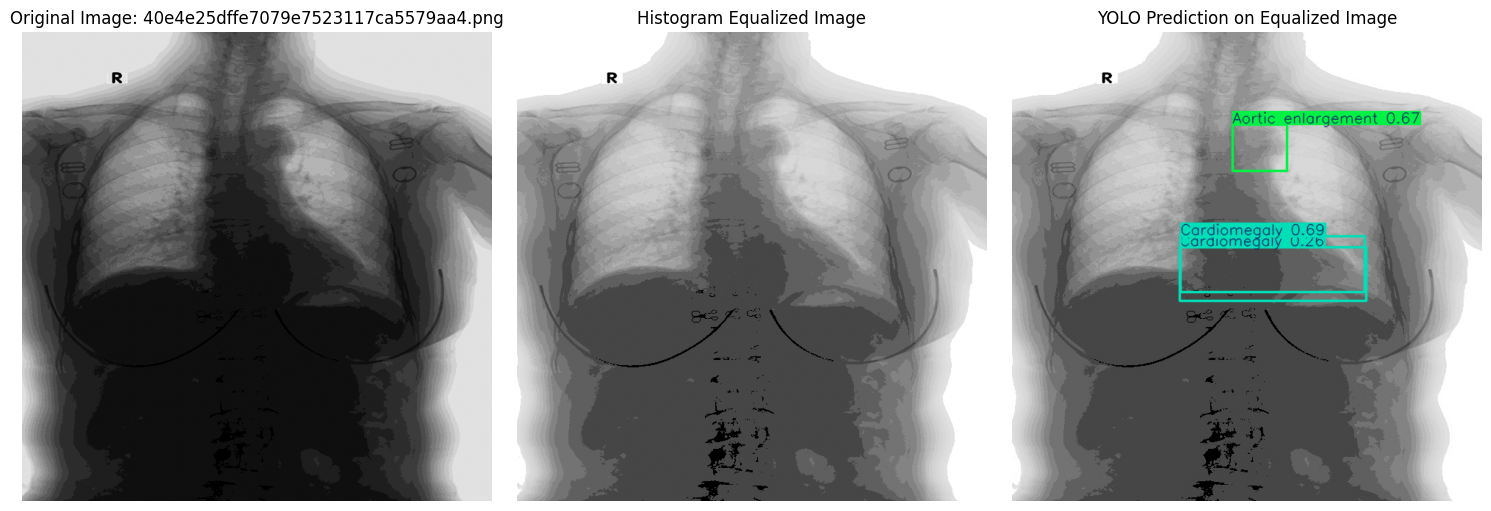

In [49]:
# Plot the original, equalized, and result images
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title(f"Original Image: {random_image_name}")
plt.axis("off")

# Equalized Image
plt.subplot(1, 3, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis("off")

# YOLO Result
plt.subplot(1, 3, 3)
plt.imshow(result_image_rgb)
plt.title("YOLO Prediction on Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()